In [128]:
# Rung 1: Exploratory Data Analysis
# This notebook explores the Students Performance in Exams dataset using pandas, Matplotlib, and Seaborn.
# The goal is to inspect the data, identify quality issues, study score distributions, compare student groups, and investigate correlations between exam scores.

In [129]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [130]:
# Set display options for pandas and seaborn
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [131]:
data_path = Path("Data") / "StudentsPerformance.csv"

# Check if the dataset exists
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {data_path.resolve()}"
    )

print(f"Dataset found at: {data_path.resolve()}")

Dataset found at: C:\Users\Fawaz\OneDrive\Desktop\KAUST\Rung_1\Data\StudentsPerformance.csv


In [132]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv(data_path)

In [133]:
# Display the first few rows of the DataFrame to inspect the data
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [134]:
# Get the number of rows and columns in the DataFrame
rows = df.shape[0]
columns = df.shape[1]

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 1000
Number of columns: 8


In [135]:
#  Get column name
df.columns.tolist()

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

In [136]:
# We are checking data information to understand the data types, non-null counts, and memory usage of the DataFrame. This will help us identify any potential issues with the dataset, such as missing values or incorrect data types.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [137]:
# We are using the describe() method to generate descriptive statistics of the DataFrame. This will provide us with insights into the central tendency, dispersion, and shape of the dataset's distribution, which can help us identify any anomalies or patterns in the data.
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [138]:
# Check for missing values
missing_values = df.isna().sum()

missing_values

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [139]:
print(f"Total missing values: {missing_values.sum()}")

Total missing values: 0


In [140]:
# Check for duplicated rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [141]:
# Data Types
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [142]:
# Categorical and Score Columns based on data types

categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
]

score_columns = [
    "math score",
    "reading score",
    "writing score",
]

In [143]:
# Verify the score columns are numeric and the categorical columns are of type string
for column in score_columns:
    print(
        f"{column}: "
        f"{pd.api.types.is_numeric_dtype(df[column])}"
    )

for column in categorical_columns:
    print(
        f"{column}: "
        f"{pd.api.types.is_string_dtype(df[column])}"
    )

math score: True
reading score: True
writing score: True
gender: True
race/ethnicity: True
parental level of education: True
lunch: True
test preparation course: True


In [144]:
# Check for impossible exam scores
score_range_summary = df[score_columns].agg(
    ["min", "max"]
)

score_range_summary

,math score,reading score,writing score
min,0,17,10
max,100,100,100


In [145]:
# Identify rows with invalid scores (less than 0 or greater than 100)
invalid_scores = df[
    (df[score_columns] < 0).any(axis=1)
    | (df[score_columns] > 100).any(axis=1)
]

print(f"Rows containing invalid scores: {len(invalid_scores)}")

invalid_scores

Rows containing invalid scores: 0


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score


In [146]:
# Count the occurrences of each category in categorical columns
for column in categorical_columns:
    print(df[column].value_counts(dropna=False))
    print("\n")

gender
female    518
male      482
Name: count, dtype: int64


race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64


parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


lunch
standard        645
free/reduced    355
Name: count, dtype: int64


test preparation course
none         642
completed    358
Name: count, dtype: int64




In [147]:
#  shows every catergory and how many times it appears
for column in categorical_columns:
    values = sorted(df[column].dropna().unique())

    print(f"{column}:")
    print(values)
    print()

gender:
['female', 'male']

race/ethnicity:
['group A', 'group B', 'group C', 'group D', 'group E']

parental level of education:
["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']

lunch:
['free/reduced', 'standard']

test preparation course:
['completed', 'none']



In [148]:
whitespace_issues = {}
# checking for whitespace issues in categorical columns
for column in categorical_columns:
    issue_count = df[column].ne(df[column].str.strip()).sum()
    whitespace_issues[column] = issue_count

pd.Series(whitespace_issues,name="whitespace issues")

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
Name: whitespace issues, dtype: int64

In [149]:
# Audit Summary of everything we have checked so far, including the number of rows and columns, missing values, duplicate rows, invalid score rows, and whitespace issues in categorical columns.
audit_summary = pd.Series({
    "rows": len(df),
    "columns": len(df.columns),
    "missing values": int(df.isna().sum().sum()),
    "duplicate rows": int(df.duplicated().sum()),
    "invalid score rows": len(invalid_scores),
    "whitespace issues": sum(whitespace_issues.values()),
})

audit_summary

rows                  1000
columns                  8
missing values           0
duplicate rows           0
invalid score rows       0
whitespace issues        0
dtype: int64

## Feature Engineering

The original dataset contains separate mathematics, reading, and writing scores. To summarize each student's overall exam performance, I created an `average score` feature.

For every student, the feature is calculated as:

Average Score = math score + reading score+ writing score / 3

This calculation is performed across each row, so every student receives their own average score.

In [150]:
def calculate_average_score(data: pd.DataFrame, columns: list[str]) -> pd.Series:
    """Calculate each student's average across the selected columns."""
    return data[columns].mean(axis=1).round(2)

df["average score"] = calculate_average_score(df, score_columns)

# Checking the first student's average score calculated manually vs using the function

first_student_manual_average = (df.loc[0, "math score"] + df.loc[0, "reading score"] + df.loc[0, "writing score"]) / 3

print("Manual calculation:", round(first_student_manual_average, 2))

print("Function result:", df.loc[0, "average score"])

# Verify that all average scores are within the valid range of 0 to 100
assert df["average score"].between(0, 100).all()

Manual calculation: 72.67
Function result: 72.67


### Pass Status

I created a Boolean `passed` feature to indicate whether a student passed all three exams.

For this analysis, the passing score is defined as 60. A student is marked as passing only when their mathematics, reading, and writing scores are all at least 60.

This threshold is an assumption made for this project. It is not an official rule provided by the dataset.

In [151]:
PASSING_SCORE = 60

In [152]:
def calculate_pass_status(data: pd.DataFrame, columns: list[str], passing_score: float) -> pd.Series:
    """Return True when every selected score meets the threshold."""
    return data[columns].ge(passing_score).all(axis=1)

df["passed"] = calculate_pass_status(df, score_columns, PASSING_SCORE)
pass_counts = (df["passed"].value_counts().rename(index={True: "Passed", False: "Did not pass"}))

pass_counts

passed
Passed          603
Did not pass    397
Name: count, dtype: int64

In [153]:
pass_percentages = (df["passed"].value_counts(normalize=True).mul(100).rename(index={True: "Passed",False: "Did not pass",}).round(2))

pass_percentages

passed
Passed          60.3
Did not pass    39.7
Name: proportion, dtype: float64

In [154]:
pass_summary = pd.DataFrame({"student count": pass_counts, "percentage": pass_percentages})

pass_summary

,student count,percentage
passed,,
Passed,603,60.3
Did not pass,397,39.7


The pass-status feature classifies students according to whether all three exam scores reached the chosen passing score of 60.

Out of 1,000 students:

- **603** passed all three exams.
- **397** did not pass at least one exam.
- The overall pass rate was **60.3%**.

The passing score is an assumption used for this project and is not an official rule provided by the dataset.

## Descriptive Statistics

Descriptive statistics provide an initial summary of the score distributions. For each score, I calculated the count, mean, median, standard deviation, minimum, and maximum.

The mean describes the arithmetic average, while the median represents the middle observation. Comparing them can help identify possible skewness.

The standard deviation measures how widely scores vary around the mean. A larger standard deviation indicates greater variation between students.

In [155]:
numerical_columns = score_columns + ["average score"]

In [156]:
summary_statistics = (df[numerical_columns].agg(["count", "mean", "median", "std", "min", "max"]).T.round(2))

summary_statistics

,count,mean,median,std,min,max
math score,1000.0,66.09,66.00,15.16,0.0,100.0
reading score,1000.0,69.17,70.00,14.60,17.0,100.0
writing score,1000.0,68.05,69.00,15.20,10.0,100.0
average score,1000.0,67.77,68.33,14.26,9.0,100.0


In [157]:
summary_statistics["range"] = (summary_statistics["max"] - summary_statistics["min"])

summary_statistics

,count,mean,median,std,min,max,range
math score,1000.0,66.09,66.00,15.16,0.0,100.0,100.0
reading score,1000.0,69.17,70.00,14.60,17.0,100.0,83.0
writing score,1000.0,68.05,69.00,15.20,10.0,100.0,90.0
average score,1000.0,67.77,68.33,14.26,9.0,100.0,91.0


In [158]:
subject_averages = (df[score_columns].mean().sort_values(ascending=False).round(2))

subject_averages

reading score    69.17
writing score    68.05
math score       66.09
dtype: float64

In [159]:
# analytically having a small difference between mean and median indicates a symmetric distribution, while a large difference suggests skewness. This comparison helps identify potential outliers or non-normal distributions in the data.

mean_median_comparison = (df[numerical_columns].agg(["mean", "median"]).T.round(2))

mean_median_comparison["difference"] = (mean_median_comparison["mean"] - mean_median_comparison["median"]).round(2)

mean_median_comparison

,mean,median,difference
math score,66.09,66.00,0.09
reading score,69.17,70.00,-0.83
writing score,68.05,69.00,-0.95
average score,67.77,68.33,-0.56


In [160]:
lowest_average_index = df["average score"].idxmin()
highest_average_index = df["average score"].idxmax()

lowest_average_student = df.loc[lowest_average_index]
highest_average_student = df.loc[highest_average_index]

# Note that the index shown is actually 2 less than the index in the csv file due to their being an empty line in the end and the header row in the csv file. So, the index in the csv file is actually 2 more than what is shown here.
print("Index of lowest average student:", lowest_average_index)
print("Index of highest average student:", highest_average_index)

Index of lowest average student: 59
Index of highest average student: 458


In [161]:
print(lowest_average_student[numerical_columns + ["passed"]], "\n")

print("\n", highest_average_student[numerical_columns + ["passed"]])

math score           0
reading score       17
writing score       10
average score      9.0
passed           False
Name: 59, dtype: object 


 math score         100
reading score      100
writing score      100
average score    100.0
passed            True
Name: 458, dtype: object


### Initial Findings

- The subject with the highest mean score was **460**, with an average of **100**.
- The subject with the lowest mean score was **61**, with an average of **9**.
- Mathematics showed a score range of **100**.
- Reading showed a score range of **83**.
- Writing showed a score range of **90**.
- The overall average-score mean was **91**, while its median was **68.33**.

The mean and median provide an initial indication of the distributions, but visualizations are needed before making stronger observations about their shape or possible outliers.

In [162]:
def calculate_rank(average_scores: pd.Series) -> pd.Series:

    """Rank average scores from highest to lowest."""

    return average_scores.rank(method="min", ascending=False).astype(int)

df["rank"] = calculate_rank(df["average score"])

In [163]:
# resorting the DataFrame based on the calculated rank to ensure that the students are ordered from highest to lowest average score. The index is reset to maintain a clean sequential order after sorting. Additionally, assertions are included to verify that all ranks are greater than or equal to 1 and that the rank column is of integer data type.
df = df.sort_values(by="rank").reset_index(drop=True)
df.head(10)
assert df["rank"].ge(1).all()
assert pd.api.types.is_integer_dtype(df["rank"])

## Score Distributions

Histograms show how student scores are distributed across mathematics, reading, writing, and overall average performance.

The shape of each distribution can reveal:

- Where scores are concentrated
- How widely scores vary
- Whether the distribution is approximately symmetric
- Whether unusually low or high values may exist

In [165]:
images_folder = Path("Images")
images_folder.mkdir(exist_ok=True)

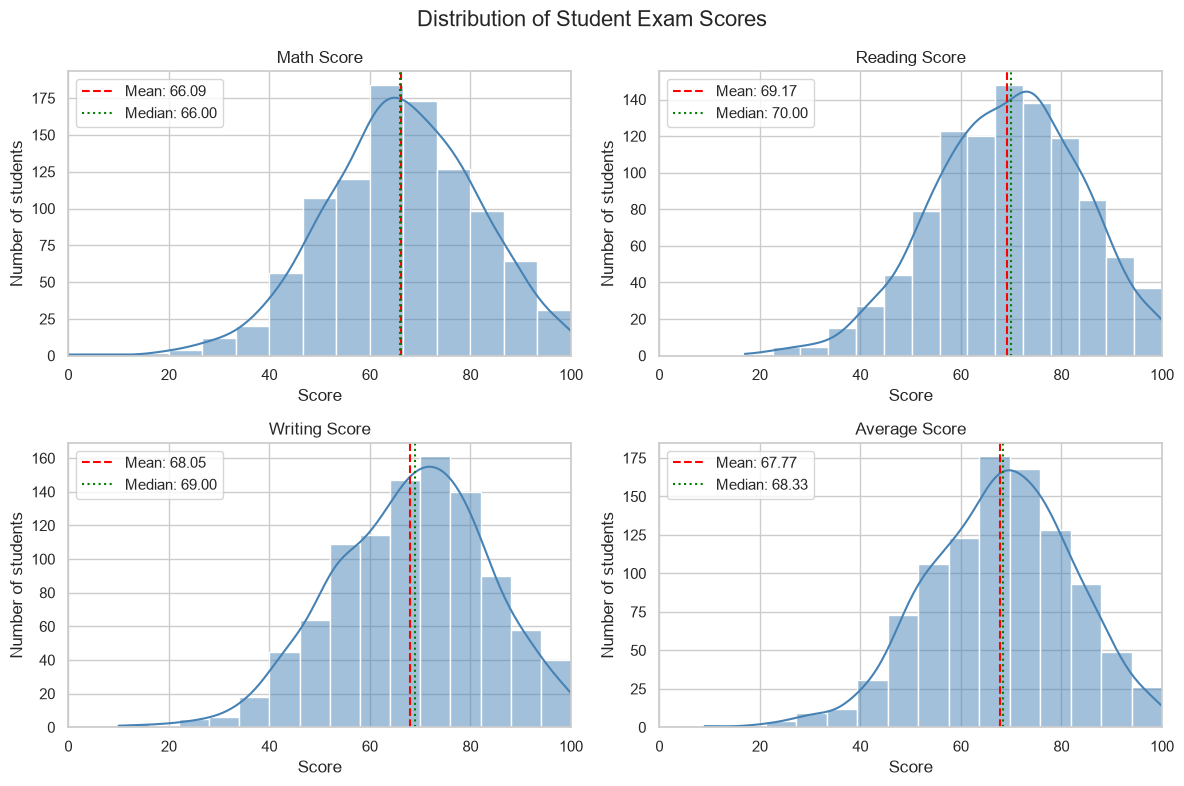

In [168]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

for column, axis in zip(numerical_columns, axes.flatten()):
    sns.histplot(data=df, x=column, bins=15, kde=True, ax=axis, color="steelblue")

    axis.axvline(df[column].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean: {df[column].mean():.2f}")

    axis.axvline(df[column].median(), color="green", linestyle=":", linewidth=1.5, label=f"Median: {df[column].median():.2f}")

    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("Score")
    axis.set_ylabel("Number of students")
    axis.set_xlim(0, 100)
    axis.legend()

fig.suptitle("Distribution of Student Exam Scores", fontsize=16)

plt.tight_layout()

plt.savefig(images_folder / "score_distributions.png", dpi=300, bbox_inches="tight")

plt.show()